# News Category Prediction Using RNN, LSTM, and Word2Vec Embeddings – Task3



**Dataset:** News Headlines Category Dataset

**Task:** Predict the news category based on the headline text

**Models:** Simple RNN · LSTM (trainable embedding) · LSTM (Word2Vec embeddings)

**Contents**:

1. Data loading & cleaning
2. Tokenization & sequence padding
3. Model building & training
4. Evaluation & error analysis
5. Gradio GUI for real-time prediction

## Import Dependencies

In [ ]:
# Install any missing packages (run once)
!pip install -q contractions wordcloud gensim gradio nltk

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import contractions

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

import gensim.downloader as gensim_api

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [ ]:
# Reproducibility
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)


print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


---
## Part I – Text Preprocessing, Tokenization & Sequence Padding

### 1.1 Load the Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Coursework AI final/news_category.csv')

In [ ]:
print("Shape:", df.shape)
df.head()

Shape: (11025, 2)


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11025 entries, 0 to 11024
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  11025 non-null  object
 1   category  11025 non-null  object
dtypes: object(2)
memory usage: 172.4+ KB
None


The dataset contains 11,025 entries with two columns: headline and category. Both columns are of object (text) type, and there are no missing values.

In [ ]:
print("\nNull counts:")
print(df.isnull().sum())


Null counts:
headline    0
category    0
dtype: int64


In [ ]:
print("\nCategory distribution:")
print(df['category'].value_counts())


Category distribution:
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64


This output shows the distribution of samples across categories, indicating a class imbalance in the dataset. SPORTS have the highest number of headlines, followed by TECH and MONEY, while CULTURE & ARTS and EDUCATION have fewer samples.

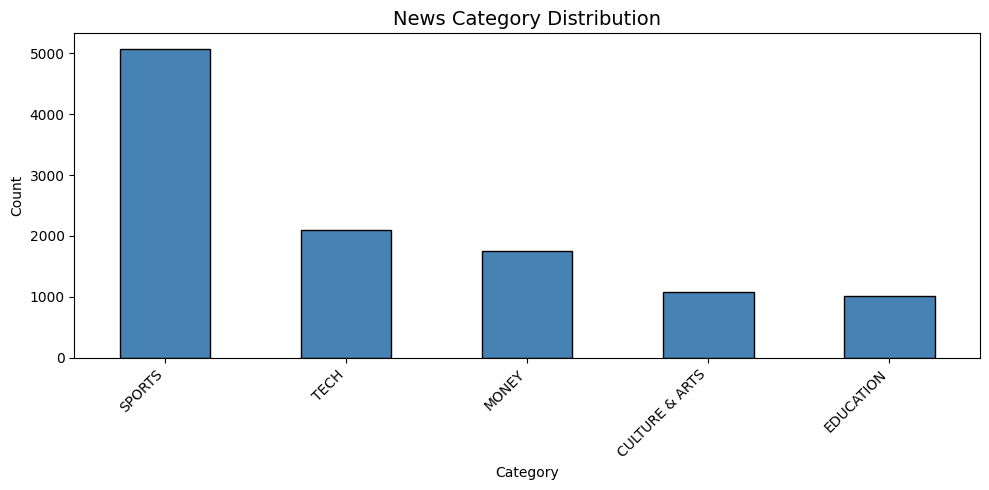

<Figure size 640x480 with 0 Axes>

In [ ]:
# category distribution
fig, ax = plt.subplots(figsize=(10, 5))
counts = df['category'].value_counts()
counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('News Category Distribution', fontsize=14)
ax.set_xlabel('Category')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.savefig('category_distribution.png')

### 1.2 Text Cleaning

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Full preprocessing pipeline for a single headline."""
    # Expand contractions: don't -> do not
    text = contractions.fix(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove mentions and hashtags (just in case)
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove numbers and special characters, keep only letters
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenise, remove stopwords, lemmatise
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return ' '.join(tokens)

This code defines a preprocessing function that cleans each headline by expanding contractions, converting text to lowercase, removing URLs, mentions, hashtags, numbers, and special characters, and then applying tokenisation, stopword removal, and lemmatisation.

In [ ]:
# Clean
df['clean_headline'] = df['headline'].apply(clean_text)

In [ ]:
print("Before:", df['headline'][6])
print("After :", df['clean_headline'][6])

Before: TikTok Search Results Riddled With Misinformation: Report
After : tiktok search result riddled misinformation report


### 1.3 Visualise Cleaned Data

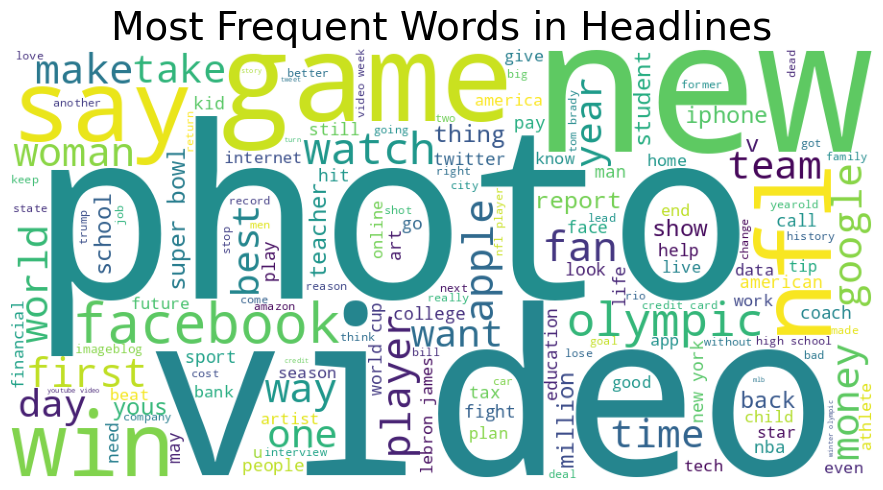

<Figure size 640x480 with 0 Axes>

In [ ]:
# Word Cloud of all cleaned headlines
all_text = ' '.join(df['clean_headline'].values)

wc = WordCloud(
    width=900, height=450,
    background_color='white',
    colormap='viridis',
    max_words=150 # Only show the 150 most frequent words
).generate(all_text)

plt.figure(figsize=(12, 5))
plt.imshow(wc)
plt.axis('off')
plt.title('Most Frequent Words in Headlines', fontsize=28)
plt.tight_layout()
plt.show()
plt.savefig('word_cloud.png')

The font size of text shows how much it appeared. For eg: video, photo, new text are largest so they are the most frequent words that appeared in the headlines.

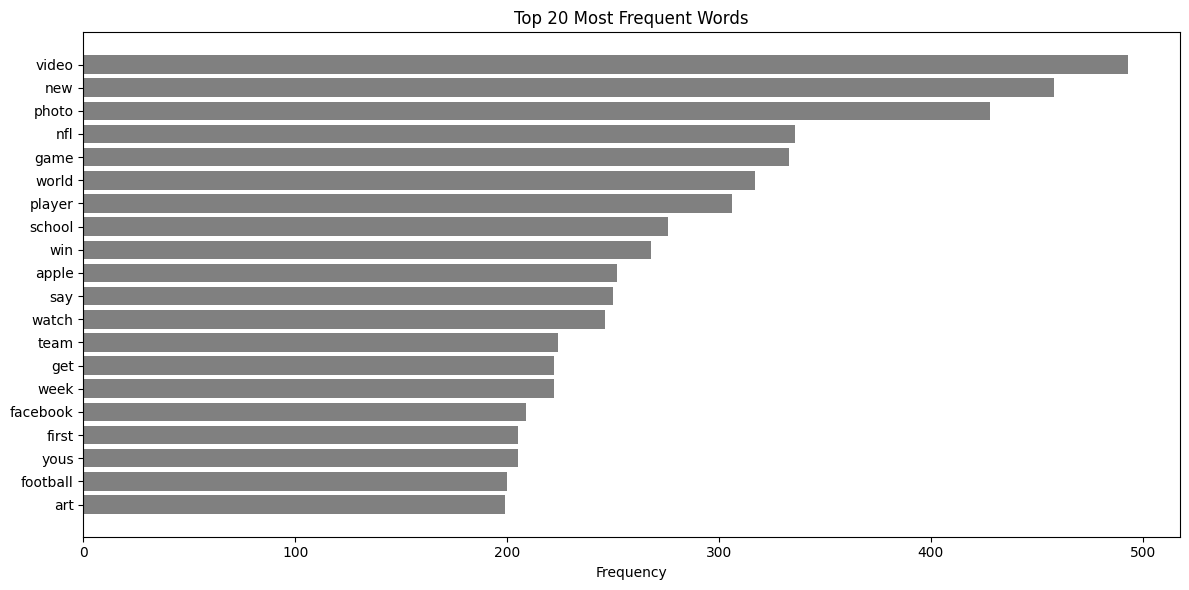

In [ ]:
# Top 20 most frequent words

# Count how many times each word appears in the whole 'clean_headline' column
# We join all headlines, split them into words, and the Counter does the math
word_freq = Counter(' '.join(df['clean_headline']).split())
top20 = word_freq.most_common(20)
# Unpack the list of tuples into two separate lists: 'words' and 'freqs'
words, freqs = zip(*top20)
plt.figure(figsize=(12, 6))
plt.barh(words[::-1], freqs[::-1], color='gray')
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.tight_layout()
plt.show()

### 1.4 Label Encoding & Train/Test Split

In [ ]:
# Encode string labels to integers
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

NUM_CLASSES = len(le.classes_)
print(f"Number of categories: {NUM_CLASSES}")
print("Classes:", le.classes_)

Number of categories: 5
Classes: ['CULTURE & ARTS' 'EDUCATION' 'MONEY' 'SPORTS' 'TECH']


Converting categorical labels into numerical form using a label encoder, creating a new label column. This 5 categories will be used as target classes for the model.

In [ ]:
# 80/20 split
X = df['clean_headline'].values
y = df['label'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

Train size: 8820  |  Test size: 2205


Splitting the dataset into training and testing sets using the cleaned headlines (clean_headline) as input features (X) and the encoded labels as targets (y).

### 1.5 Tokenisation & Padding

In [ ]:
# Initializing
# VOCAB_SIZE is the limit of how many unique words we want to keep
# <OOV> replaces words the model hasn't seen before during training
VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')

tokenizer.fit_on_texts(X_train)

Initializing a tokenizer with a vocabulary size limit of 20,000 words and an out-of-vocabulary (OOV) token to handle unseen words. It is then fitted on the training data (X_train), allowing it to learn the most frequent words and build a word-to-index mapping.

In [ ]:
# Converting the cleaned text into sequences of integers using the fitted tokenizer for both training and testing data.
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

In [ ]:
# Use 95th percentile of training sequence lengths to determine an optimal maximum length (11), helping to avoid excessive padding while retaining most of the information.
lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"95th percentile sequence length: {MAX_LEN}")

95th percentile sequence length: 11


In [ ]:
# Pad sequences to MAX_LEN
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad  shape: {X_test_pad.shape}")

X_train_pad shape: (8820, 11)
X_test_pad  shape: (2205, 11)


pads all tokenized sequences to a fixed length of 11 (MAX_LEN) using post-padding and post-truncation to ensure uniform input size for the model.

In [ ]:
# One-hot encode labels for categorical cross-entropy
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

Converts the integer-encoded class labels into one-hot encoded vectors using categorical encoding. This transformation is required for categorical cross-entropy loss, allowing the model to output probabilities across all 5 classes during training and evaluation.

---
## Part II – Model Building & Training

Building three models:
1. **Model 1** – Simple RNN with trainable Embedding
2. **Model 2** – LSTM with trainable Embedding
3. **Model 3** – LSTM with pretrained Word2Vec Embedding

In [ ]:
# Shared hyper-parameters
EMBED_DIM  = 100   # embedding vector size
EPOCHS     = 20
BATCH_SIZE = 32

In [ ]:
# Callbacks used by all models
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=2, min_lr=1e-6, verbose=1)

### 2.1 Model 1 – Simple RNN

In [ ]:
model1 = Sequential(name='SimpleRNN_Model')
model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
model1.add(SimpleRNN(64, return_sequences=False))
model1.add(Dropout(0.4))
model1.add(Dense(64, activation='tanh'))
model1.add(Dense(NUM_CLASSES, activation='softmax'))

Embedding layer is converting word indices into dense vectors.

SimpleRNN layer with 64 units to capture sequential patterns.

A dropout layer is added to reduce overfitting, followed by a fully connected dense layer with ReLU activation.

Softmax layer for multi-class classification across the five categories.

In [ ]:
model1.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model1.build((None, MAX_LEN))
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_47 (Embedding)        │ (None, 11, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_17 (SimpleRNN)       │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,015,045 (7.69 MB)

 Trainable params: 2,015,045 (7.69 MB)

 Non-trainable params: 0 (0.00 B)

This output shows the model architecture of the SimpleRNN network before it has been built. Since the model has not yet received input data, the output shapes and parameter counts are not initialized, resulting in undefined shapes (?) and zero parameters.

In [ ]:
import time

start_time = time.time()
history1 = model1.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr, ModelCheckpoint('best_RNN_model1.h5',monitor='val_accuracy',save_best_only=True,verbose=1)],
    verbose=1
)
end_time = time.time()

# Calculate total duration
training_duration_model1 = end_time - start_time
print(f"Total Training Time: {training_duration_model1:.2f} seconds")

Epoch 1/20
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3723 - loss: 1.4981
Epoch 1: val_accuracy improved from None to 0.57993, saving model to best_RNN_model1.h5



Epoch 1: finished saving model to best_RNN_model1.h5
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.4480 - loss: 1.3787 - val_accuracy: 0.5799 - val_loss: 1.0219 - learning_rate: 0.0010
Epoch 2/20
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5566 - loss: 1.1132
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0004000000189989805.

Epoch 2: val_accuracy improved from 0.57993 to 0.60544, saving model to best_RNN_model1.h5



Epoch 2: finished saving model to best_RNN_model1.h5
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.5838 - loss: 1.0455 - val_accuracy: 0.6054 - val_loss: 0.9387 - learning_rate: 0.0010
Epoch 3/20
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6129 - loss: 0.9268
Epoch 3: val_accuracy did not improve from 0.60544
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6277 - loss: 0.8775 - val_accuracy: 0.5890 - val_loss: 0.9829 - learning_rate: 4.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
Total Training Time: 27.12 seconds


In [ ]:
_, acc1 = model1.evaluate(X_test_pad, y_test_cat, verbose=0)
print(f"Test Accuracy for Model 1 (Simple RNN): {acc1:.4f}")

Test Accuracy for Model 1 (Simple RNN): 0.5773


### 2.2 Model 2 – LSTM with Trainable Embedding

In [ ]:
from tensorflow.keras.layers import SpatialDropout1D
model2 = Sequential(name='LSTM_Trainable_Embedding')
model2.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
model2.add(LSTM(128, return_sequences=True))
model2.add(LSTM(64))
model2.add(Dropout(0.3))
model2.add(Dense(64, activation='tanh'))
model2.add(Dense(NUM_CLASSES, activation='softmax'))


In [ ]:
model2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model2.build((None, MAX_LEN))
model2.summary()

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_56 (Embedding)        │ (None, 11, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_72 (LSTM)                  │ (None, 11, 128)        │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_73 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171,141 (8.28 MB)

 Trainable params: 2,171,141 (8.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start_time = time.time()
history2 = model2.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr, ModelCheckpoint('best_LSTM_model2.h5',monitor='val_accuracy',save_best_only=True,verbose=1)],
    verbose=1
)
end_time = time.time()

# Calculate total duration
training_duration_model2 = end_time - start_time
print(f"Total Training Time: {training_duration_model2:.2f} seconds")

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8055 - loss: 0.5356
Epoch 1: val_accuracy improved from None to 0.79592, saving model to best_LSTM_model2.h5



Epoch 1: finished saving model to best_LSTM_model2.h5
221/221 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.8377 - loss: 0.4405 - val_accuracy: 0.7959 - val_loss: 0.6005 - learning_rate: 4.0000e-04
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9186 - loss: 0.2620
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00016000000759959222.

Epoch 2: val_accuracy did not improve from 0.79592
221/221 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9359 - loss: 0.2032 - val_accuracy: 0.7812 - val_loss: 0.7595 - learning_rate: 4.0000e-04
Epoch 3/20
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9601 - loss: 0.1349
Epoch 3: val_accuracy did not improve from 0.79592
221/221 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9719 - loss: 0.0984 - val_accuracy: 0.7885 - val_loss: 0.7988 - learning_rate: 1.6000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
Total Training Time: 37.38 seconds


In [ ]:
_, acc2 = model2.evaluate(X_test_pad, y_test_cat, verbose=0)
print(f"Test Accuracy for Model 2 (LSTM Trainable Embedding): {acc2:.4f}")

Test Accuracy for Model 2 (LSTM Trainable Embedding): 0.8045


### 2.3 Model 3 – LSTM with Pretrained Word2Vec Embeddings

In [ ]:
# Load Google News Word2Vec (100-dim glove alternative that gensim hosts)
print("Downloading pretrained word vectors (glove-wiki-gigaword-100)...")
w2v_model = gensim_api.load('glove-wiki-gigaword-100')
print("Done!")

Done!


In [ ]:
# Build embedding matrix from the tokenizer's word index
word_index = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))

found = 0
for word, idx in word_index.items():
    if idx < VOCAB_SIZE and word in w2v_model:
        embedding_matrix[idx] = w2v_model[word]
        found += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f"Word coverage by pretrained vectors: {coverage:.1f}%")

Word coverage by pretrained vectors: 89.8%


In [ ]:
model3 = Sequential(name='LSTM_Word2Vec_Embedding')

# Embedding layer initialised with pretrained weights; frozen first
model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
    input_length=MAX_LEN,
    weights=[embedding_matrix],
    trainable=False        # freeze pretrained weights
))
model3.add(LSTM(128, return_sequences=True))
model3.add(LSTM(64))
model3.add(Dropout(0.3))
model3.add(Dense(64, activation='tanh'))
model3.add(Dense(NUM_CLASSES, activation='softmax'))

model3.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model3.build((None, MAX_LEN))
model3.summary()

Model: "LSTM_Word2Vec_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 11, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 11, 128)        │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171,141 (8.28 MB)

 Trainable params: 171,141 (668.52 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

In [ ]:
start_time = time.time()
history3 = model3.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr, ModelCheckpoint('best_Word2Vec_model3.h5',monitor='val_accuracy',save_best_only=True,verbose=1)],
    verbose=1
)
end_time = time.time()

# Calculate total duration
training_duration_model3 = end_time - start_time
print(f"Total Training Time: {training_duration_model3:.2f} seconds")

Epoch 1/20
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6433 - loss: 0.9542
Epoch 1: val_accuracy improved from None to 0.82256, saving model to best_Word2Vec_model3.h5



Epoch 1: finished saving model to best_Word2Vec_model3.h5
221/221 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.7560 - loss: 0.6987 - val_accuracy: 0.8226 - val_loss: 0.4965 - learning_rate: 0.0010
Epoch 2/20
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8379 - loss: 0.4838
Epoch 2: val_accuracy improved from 0.82256 to 0.82653, saving model to best_Word2Vec_model3.h5



Epoch 2: finished saving model to best_Word2Vec_model3.h5
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.8457 - loss: 0.4632 - val_accuracy: 0.8265 - val_loss: 0.4849 - learning_rate: 0.0010
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8608 - loss: 0.4178
Epoch 3: val_accuracy improved from 0.82653 to 0.83617, saving model to best_Word2Vec_model3.h5



Epoch 3: finished saving model to best_Word2Vec_model3.h5
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.8665 - loss: 0.4023 - val_accuracy: 0.8362 - val_loss: 0.4718 - learning_rate: 0.0010
Epoch 4/20
219/221 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8708 - loss: 0.3815
Epoch 4: val_accuracy improved from 0.83617 to 0.84751, saving model to best_Word2Vec_model3.h5



Epoch 4: finished saving model to best_Word2Vec_model3.h5
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8801 - loss: 0.3601 - val_accuracy: 0.8475 - val_loss: 0.4662 - learning_rate: 0.0010
Epoch 5/20
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8873 - loss: 0.3381
Epoch 5: val_accuracy improved from 0.84751 to 0.85658, saving model to best_Word2Vec_model3.h5



Epoch 5: finished saving model to best_Word2Vec_model3.h5
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.8965 - loss: 0.3122 - val_accuracy: 0.8566 - val_loss: 0.4756 - learning_rate: 0.0010
Epoch 6/20
219/221 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9015 - loss: 0.2993
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 6: val_accuracy did not improve from 0.85658
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9087 - loss: 0.2746 - val_accuracy: 0.8560 - val_loss: 0.5083 - learning_rate: 0.0010
Epoch 7/20
219/221 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9212 - loss: 0.2417
Epoch 7: val_accuracy did not improve from 0.85658
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9296 - loss: 0.2161 - val_accuracy: 0.8532 - val_loss: 0.5351 - learning_rate: 5.0000e-04
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
Total Training Time: 64.75 seconds


In [ ]:
_, acc3 = model3.evaluate(X_test_pad, y_test_cat, verbose=0)
print(f"Test Accuracy for Model 3 (LSTM Word2Vec Embedding): {acc3:.4f}")

Test Accuracy for Model 3 (LSTM Word2Vec Embedding): 0.8481


---
## Part III – Evaluation & Visualisation

### 3.1 Training Curves

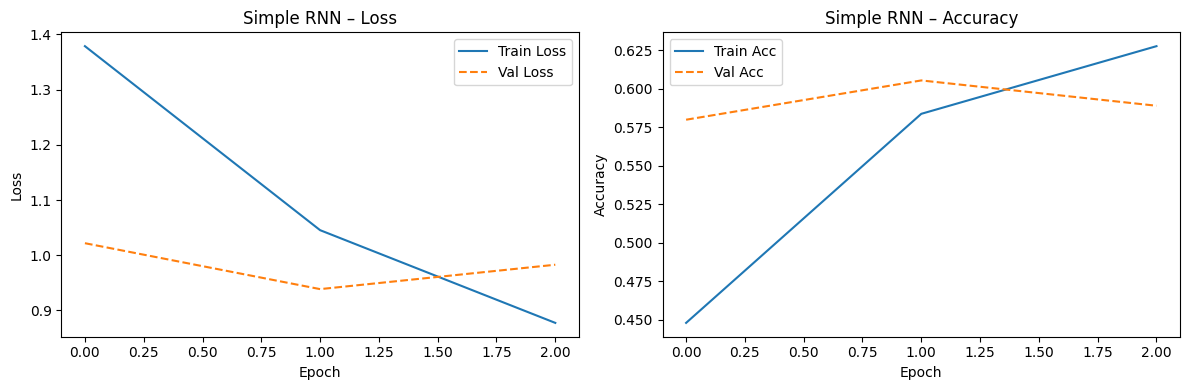

In [ ]:
def plot_history(history, model_name):
    """Plot training vs validation loss and accuracy."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss',  linestyle='--')
    axes[0].set_title(f'{model_name} – Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc',  linestyle='--')
    axes[1].set_title(f'{model_name} – Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    save_path = f'{model_name}_training_curves.png'
    plt.savefig(save_path)
    plt.show()

plot_history(history1, 'Simple RNN')

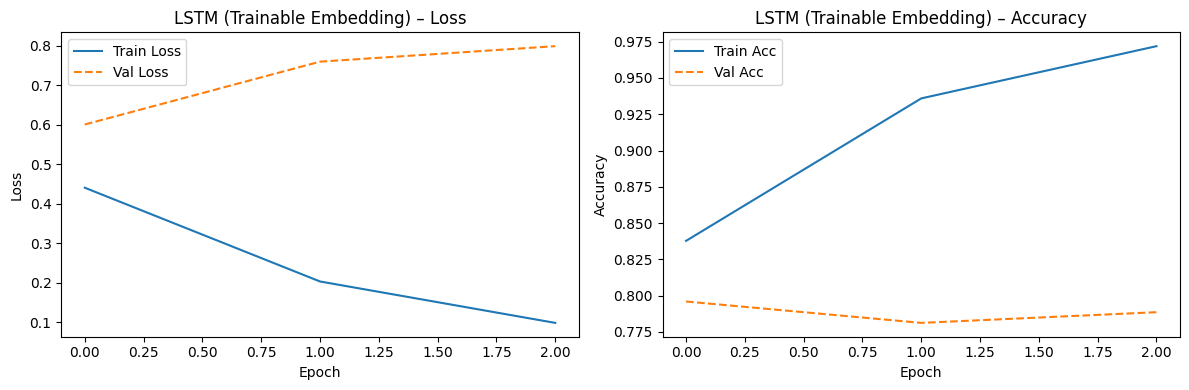

In [ ]:
plot_history(history2, 'LSTM (Trainable Embedding)')

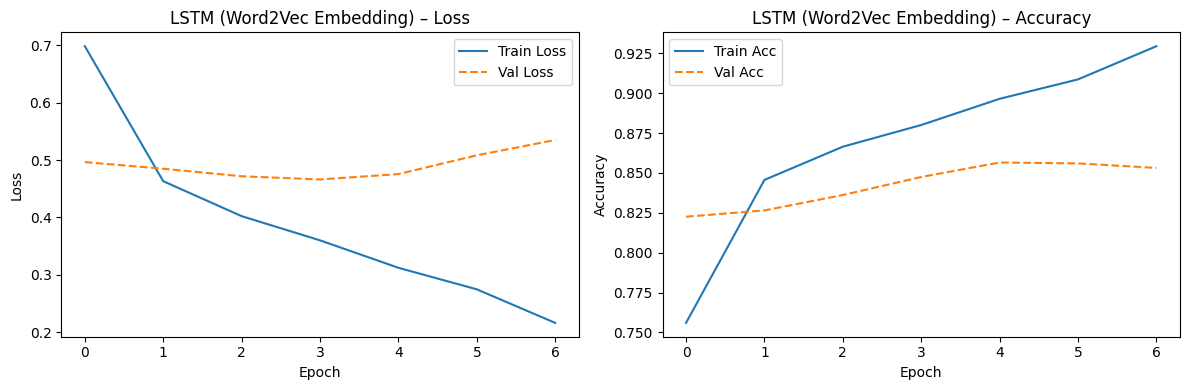

In [ ]:
plot_history(history3, 'LSTM (Word2Vec Embedding)')

### 3.2 Test Set Accuracy Comparison

Test Accuracies:
  Simple RNN: 0.5773
  LSTM (Trainable): 0.8045
  LSTM (Word2Vec): 0.8481


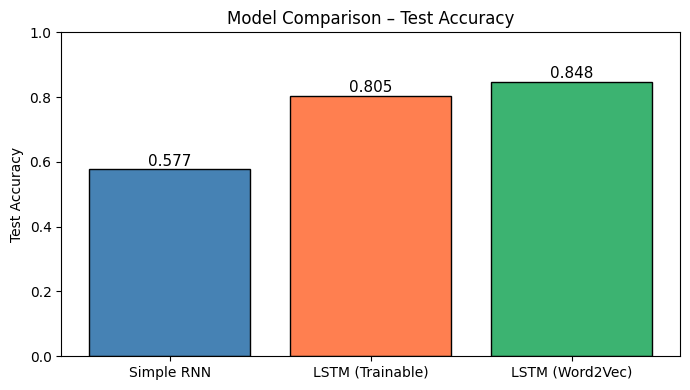

In [ ]:
# Evaluate all models on the test set

model_names = ['Simple RNN', 'LSTM (Trainable)', 'LSTM (Word2Vec)']
accuracies  = [acc1, acc2, acc3]

print("Test Accuracies:")
for name, acc in zip(model_names, accuracies):
    print(f"  {name}: {acc:.4f}")

# Bar chart comparison
plt.figure(figsize=(7, 4))
bars = plt.bar(model_names, accuracies, color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='black')
plt.ylim(0, 1.0)
plt.ylabel('Test Accuracy')
plt.title('Model Comparison – Test Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

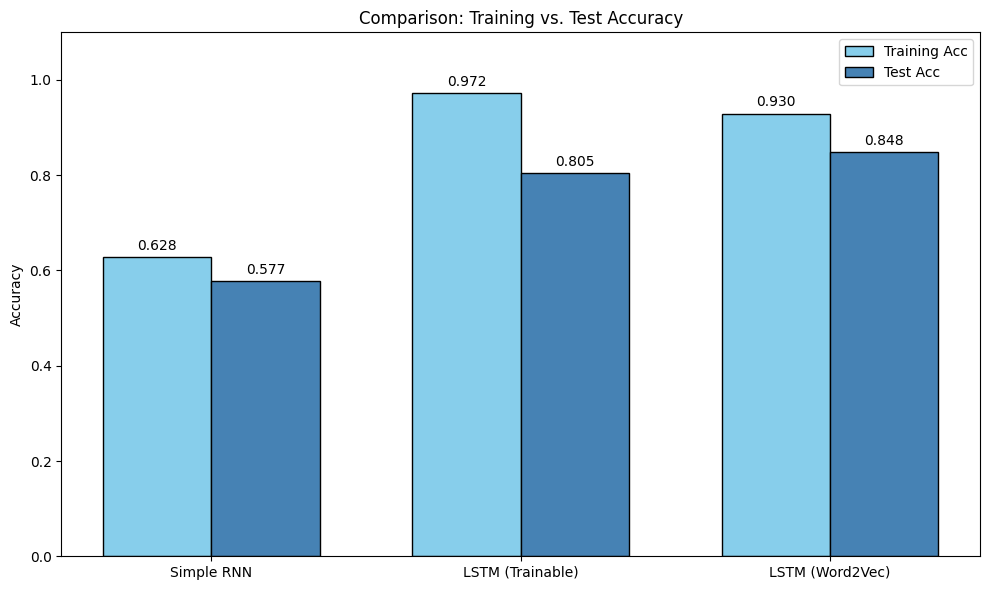

In [ ]:
# Extract the final training accuracy from history objects
# (Note: we take the last value in the history list)
train_acc1 = history1.history['accuracy'][-1]
train_acc2 = history2.history['accuracy'][-1]
train_acc3 = history3.history['accuracy'][-1]

train_accs = [train_acc1, train_acc2, train_acc3]
test_accs  = [acc1, acc2, acc3] # from your previous cell

# Set up the bar chart
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_accs, width, label='Training Acc', color='skyblue', edgecolor='black')
rects2 = ax.bar(x + width/2, test_accs, width, label='Test Acc', color='steelblue', edgecolor='black')

# Add labels and formatting
ax.set_ylabel('Accuracy')
ax.set_title('Comparison: Training vs. Test Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1) # Extra space for labels
ax.legend()

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('model_accuracy_comparison.png') # Saving as requested earlier
plt.show()

### 3.3 Confusion Matrix & Classification Report

In [ ]:
def evaluate_model(model, X_test_pad, y_test, le, title):
    """Print classification report and plot confusion matrix."""
    y_pred = np.argmax(model.predict(X_test_pad), axis=1)

    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix – {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return y_pred


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

  Simple RNN
Test Accuracy: 0.5773

                precision    recall  f1-score   support

CULTURE & ARTS       1.00      0.00      0.01       215
     EDUCATION       0.33      0.00      0.01       203
         MONEY       0.31      0.65      0.42       351
        SPORTS       0.82      0.91      0.87      1015
          TECH       0.35      0.28      0.31       421

      accuracy                           0.58      2205
     macro avg       0.56      0.37      0.32      2205
  weighted avg       0.62      0.58      0.53      2205



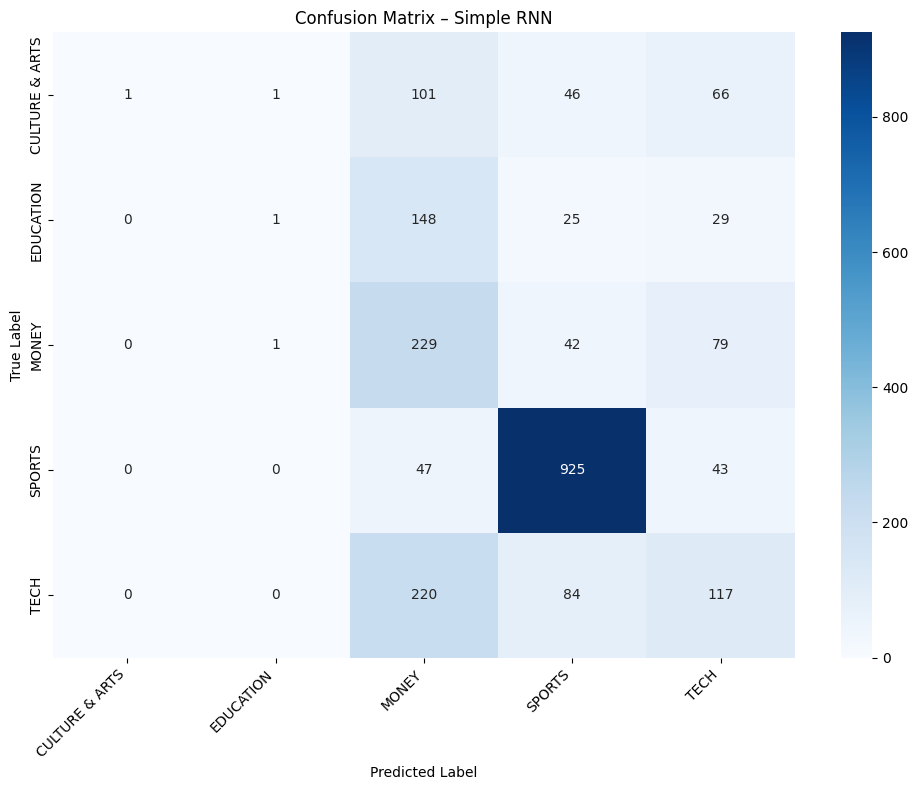

In [ ]:
y_pred1 = evaluate_model(model1, X_test_pad, y_test, le, 'Simple RNN')

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

  LSTM (Trainable Embedding)
Test Accuracy: 0.8045

                precision    recall  f1-score   support

CULTURE & ARTS       0.69      0.57      0.62       215
     EDUCATION       0.69      0.56      0.62       203
         MONEY       0.71      0.75      0.73       351
        SPORTS       0.86      0.95      0.90      1015
          TECH       0.83      0.74      0.78       421

      accuracy                           0.80      2205
     macro avg       0.76      0.71      0.73      2205
  weighted avg       0.80      0.80      0.80      2205



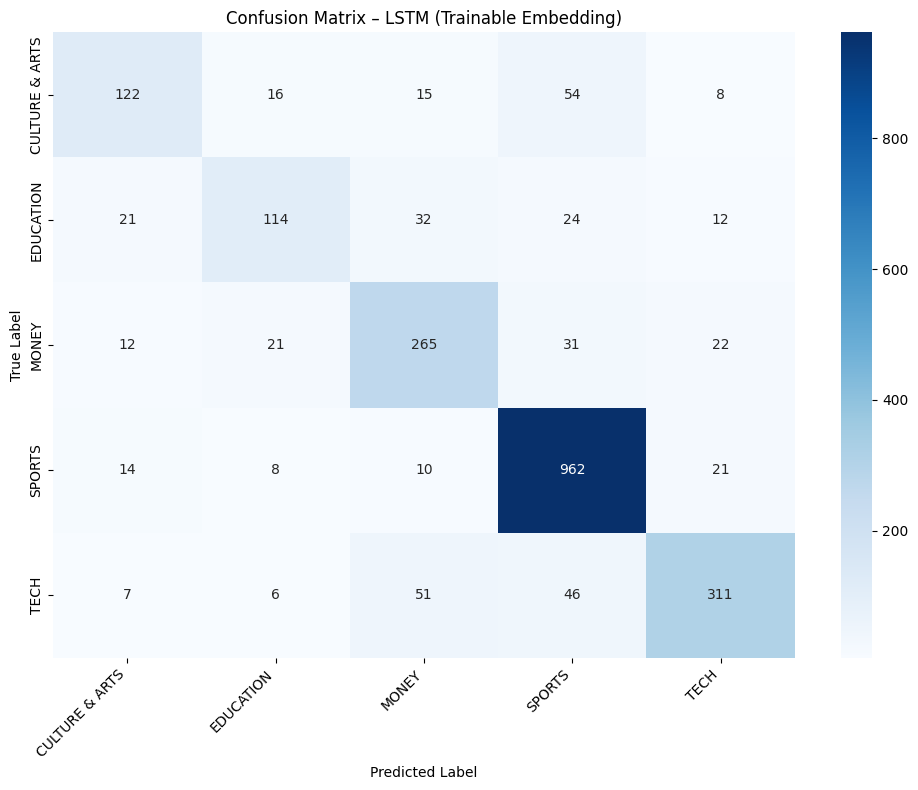

In [ ]:
y_pred2 = evaluate_model(model2, X_test_pad, y_test, le, 'LSTM (Trainable Embedding)')

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

  LSTM (Word2Vec Embedding)
Test Accuracy: 0.8481

                precision    recall  f1-score   support

CULTURE & ARTS       0.82      0.69      0.75       215
     EDUCATION       0.71      0.81      0.75       203
         MONEY       0.75      0.84      0.79       351
        SPORTS       0.93      0.90      0.92      1015
          TECH       0.83      0.82      0.83       421

      accuracy                           0.85      2205
     macro avg       0.81      0.81      0.81      2205
  weighted avg       0.85      0.85      0.85      2205



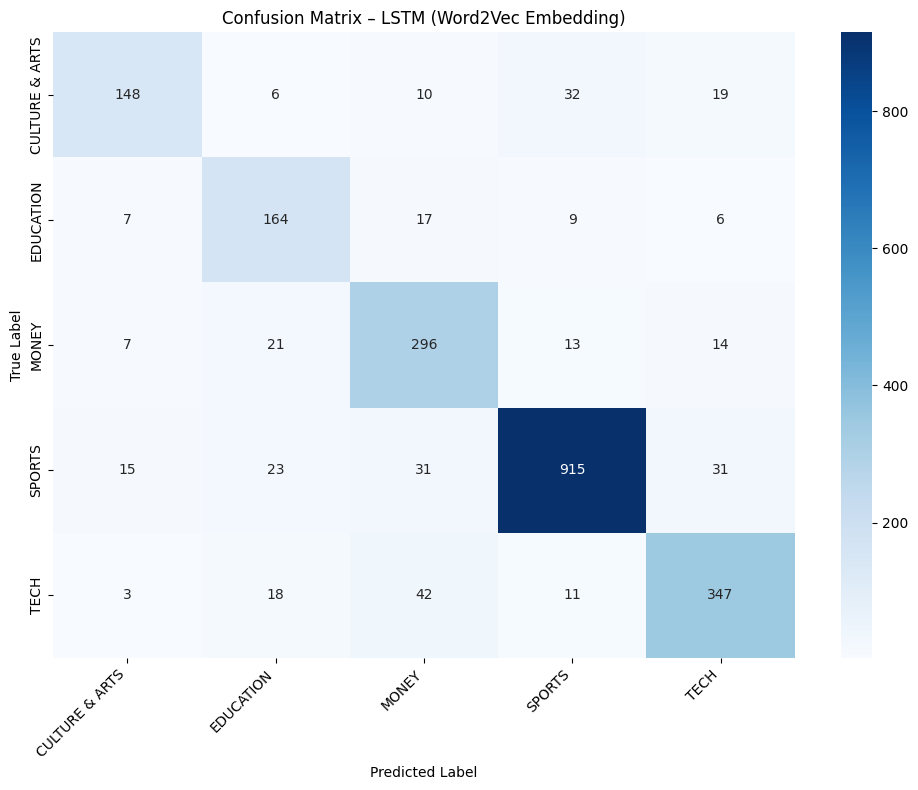

In [ ]:
y_pred3 = evaluate_model(model3, X_test_pad, y_test, le, 'LSTM (Word2Vec Embedding)')

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd


# Build comparison dataframe
models = {
    'Simple RNN':        y_pred1,
    'LSTM (Trainable)':  y_pred2,
    'LSTM (Word2Vec)':   y_pred3,
}

# Get training durations
training_durations = {
    'Simple RNN': training_duration_model1,
    'LSTM (Trainable)': training_duration_model2,
    'LSTM (Word2Vec)': training_duration_model3,
}

rows = []
for name, y_pred in models.items():
    rows.append({
        'Model':         name,
        'Accuracy':      round(accuracy_score(y_test, y_pred), 4),
        'Precision':     round(precision_score(y_test, y_pred, average='weighted'), 4),
        'Recall':        round(recall_score(y_test, y_pred, average='weighted'), 4),
        'F1 (Weighted)': round(f1_score(y_test, y_pred, average='weighted'), 4),
        'F1 (Macro)':    round(f1_score(y_test, y_pred, average='macro'), 4),
        'Time Taken (s)': round(training_durations[name], 2),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
print(comparison_df.to_string())

                  Accuracy  Precision  Recall  F1 (Weighted)  F1 (Macro)  Time Taken (s)
Model                                                                                   
Simple RNN          0.5773     0.6235  0.5773         0.5260      0.3225           27.12
LSTM (Trainable)    0.8045     0.7995  0.8045         0.7992      0.7321           37.38
LSTM (Word2Vec)     0.8481     0.8529  0.8481         0.8490      0.8083           64.75


---
## Part IV – Error Analysis

### 4.1 Misclassified Examples (Best Model)

In [ ]:
# Find misclassified samples
best_pred = y_pred3

wrong_mask = best_pred != y_test
wrong_headlines  = X_test[wrong_mask]
wrong_true_labels = le.inverse_transform(y_test[wrong_mask])
wrong_pred_labels = le.inverse_transform(best_pred[wrong_mask])

print("Sample Misclassified Headlines (showing first 5):\n")
for i in range(min(5, len(wrong_headlines))):
    print(f"Headline : {wrong_headlines[i]}")
    print(f"  True    : {wrong_true_labels[i]}")
    print(f"  Predicted: {wrong_pred_labels[i]}")
    print()

Sample Misclassified Headlines (showing first 5):

Headline : new york giant victor cruz reveals secret staying sane
  True    : SPORTS
  Predicted: CULTURE & ARTS

Headline : need six strike
  True    : TECH
  Predicted: MONEY

Headline : nd fifth accident samantha rippner video
  True    : CULTURE & ARTS
  Predicted: TECH

Headline : roll roll lausds civil right ipads four year later
  True    : EDUCATION
  Predicted: TECH

Headline : rap genius sorry moron
  True    : TECH
  Predicted: SPORTS



### 4.2 Analysis of Errors

**Observations from misclassified examples:**

1. **Ambiguous headlines**: Some headlines don't contain strong category-specific keywords and can plausibly belong to multiple categories. For example, a headline like *"Trump calls for major changes"* could fall under POLITICS or WORLD NEWS.

2. **Short headlines**: Very short headlines (1–3 words after cleaning) lose too much context after preprocessing, making it hard for any model to infer the correct category.

3. **Class imbalance**: If some categories have significantly fewer samples, the model has less exposure to those patterns, leading to higher error rates on minority classes.

**Model Complexity vs Performance:**
- Simple RNN struggles with long-range dependencies due to the vanishing gradient problem.
- LSTM handles sequential dependencies better, which is why it outperforms RNN.
- Word2Vec LSTM can leverage semantic relationships between words, though the benefit depends on vocabulary coverage.

**Possible Improvements:**
- Use Bidirectional LSTM to capture context from both directions.
- Fine-tune a transformer-based model (e.g., BERT) for better contextual understanding.
- Apply class-weighting during training to handle imbalanced categories.
- Use more aggressive data augmentation (back-translation, synonym replacement).

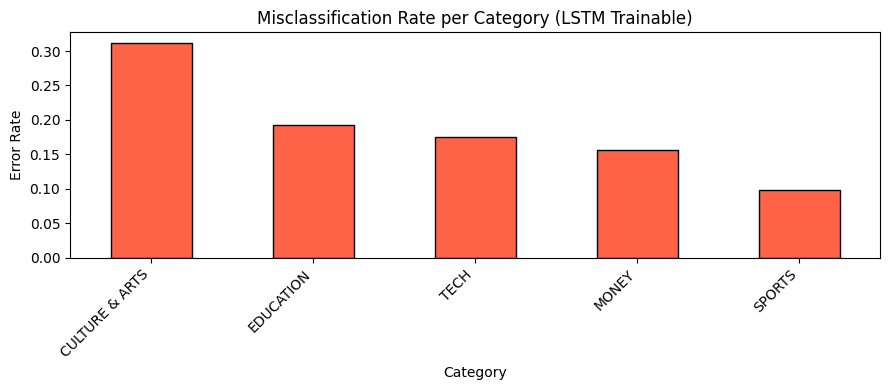

In [ ]:
# Misclassification rate per category
error_df = pd.DataFrame({
    'true': le.inverse_transform(y_test),
    'pred': le.inverse_transform(best_pred)
})
error_df['correct'] = error_df['true'] == error_df['pred']

error_rate = error_df.groupby('true')['correct'].apply(lambda x: 1 - x.mean()).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
error_rate.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Misclassification Rate per Category (LSTM Trainable)')
plt.ylabel('Error Rate')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Part V – GUI for Real-Time Prediction (Gradio)

In [ ]:
import gradio as gr

def predict_category(headline):
    """Clean, tokenise, pad, and predict category for a single headline."""
    cleaned = clean_text(headline)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Get probabilities from best model (model2)
    probs = model3.predict(padded, verbose=0)[0]
    pred_class = le.classes_[np.argmax(probs)]
    confidence = float(np.max(probs))

    # Return dict of all class probabilities for display
    result = {le.classes_[i]: float(probs[i]) for i in range(NUM_CLASSES)}
    return result

In [ ]:
!pip install --upgrade gradio

In [ ]:
# Build a simple Gradio interface
iface = gr.Interface(
    fn=predict_category,
    inputs=gr.Textbox(
        lines=2,
        placeholder="Enter a news headline here...",
        label="News Headline"
    ),
    outputs=gr.Label(num_top_classes=5, label="Predicted Category"),
    title="News Category Predictor",
    description="Type a news headline and the model will predict its category.",
    examples=[
        ["Scientists discover new species of dinosaur in Argentina"],
        ["Stock market hits record high as inflation fears ease"],
        ["President signs new climate change agreement"],
        ["Champions League final ends in dramatic penalty shootout"],
    ],

    theme=gr.themes.Soft()
)

# Launch the GUI (share=False for local; set share=True for a public link)
iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://17d0bf06c63b231fb8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
